1. Generate SFCC data

In [1]:
import numpy as np
import pandas as pd
from scipy.stats import qmc

# =========================================================
# 1. 读取由实测SFCC拟合得到的Form 2参数范围
# =========================================================
form2_fit = pd.read_csv(
    r"D:\UW Madsion\Operator\SFC_inverse\Operator experiment"
    r"\SC_DION\Dataset\SFCC data\form2_fitted_params.csv"
)

# 使用2%–98%分位数，避免个别极端拟合参数控制抽样范围
theta_res_min, theta_res_max = np.quantile(
    form2_fit["theta_res"],
    [0.02, 0.98]
)

gamma_min, gamma_max = np.quantile(
    form2_fit["gamma"],
    [0.02, 0.98]
)

print("theta_res range:", theta_res_min, theta_res_max)
print("gamma range:", gamma_min, gamma_max)

theta_res range: 4.360824258912948e-15 0.40836877118655185
gamma range: 0.06312010423868063 7.86299086588089


In [2]:
T50_min = gamma_min * np.sqrt(np.log(2.0))
T50_max = gamma_max * np.sqrt(np.log(2.0))

print("T50 range:", T50_min, T50_max)

T50 range: 0.05255093384066809 6.5463693028799925


In [3]:
# =========================================================
# 2. Latin hypercube sampling
# =========================================================
n_case = 150
seed = 2026

sampler = qmc.LatinHypercube(
    d=3,
    seed=seed
)

sample_unit = sampler.random(n=n_case)

# theta_res：保持在实测拟合数据范围内
theta_res_sample = (
    theta_res_min
    + sample_unit[:, 0]
    * (theta_res_max - theta_res_min)
)

# T50：保持与当前Form 2曲线的相变区间相当
T50_sample = (
    T50_min
    + sample_unit[:, 1]
    * (T50_max - T50_min)
)

# Form 3形状参数
n_min = 1.2
n_max = 5.0

n_sample = (
    n_min
    + sample_unit[:, 2]
    * (n_max - n_min)
)

In [4]:
m_sample = 1.0 - 1.0 / n_sample

alpha_sample = (
    (2.0**(1.0 / m_sample) - 1.0)
    ** (1.0 / n_sample)
) / T50_sample

In [5]:
form3_test = pd.DataFrame({
    "curve_id": np.arange(1, n_case + 1),
    "form_id": np.full(n_case, 3),
    "alpha": alpha_sample,
    "beta": np.zeros(n_case),
    "theta_res": theta_res_sample,
    "gamma": np.zeros(n_case),
    "n": n_sample
})

form3_test.to_csv(
    "form3_sampled_OOD_test.csv",
    index=False
)

print(form3_test.head())
print("Number of cases:", len(form3_test))

   curve_id  form_id     alpha  beta  theta_res  gamma         n
0         1        3  0.681254   0.0   0.146526    0.0  4.633496
1         2        3  0.701901   0.0   0.124224    0.0  1.585307
2         3        3  0.239950   0.0   0.335121    0.0  2.931463
3         4        3  0.219811   0.0   0.020968    0.0  2.418030
4         5        3  0.215481   0.0   0.172506    0.0  3.694949
Number of cases: 150


In [6]:
theta_sat = 0.5
T_check = np.linspace(-15.0, 0.0, 200)


def theta_vg(
    T,
    theta_res,
    alpha,
    n,
    theta_sat=0.5
):
    T = np.asarray(T, dtype=float)
    x = np.maximum(-T, 1e-6)

    m = 1.0 - 1.0 / n

    theta = (
        theta_res
        + (theta_sat - theta_res)
        * (1.0 + (alpha * x)**n)**(-m)
    )

    return np.clip(theta, 0.0, theta_sat)


all_curves = []

for _, row in form3_test.iterrows():

    theta = theta_vg(
        T_check,
        row["theta_res"],
        row["alpha"],
        row["n"]
    )

    # 温度从-15升到0时，未冻水含量应单调增加
    assert np.all(np.diff(theta) >= -1e-10)

    assert np.min(theta) >= 0.0
    assert np.max(theta) <= 0.5 + 1e-10

    all_curves.append(theta)

all_curves = np.asarray(all_curves)

print("Curve array shape:", all_curves.shape)
print(
    "theta(-15 °C) range:",
    all_curves[:, 0].min(),
    all_curves[:, 0].max()
)

Curve array shape: (150, 200)
theta(-15 °C) range: 0.0012877276757720375 0.40980210006888296


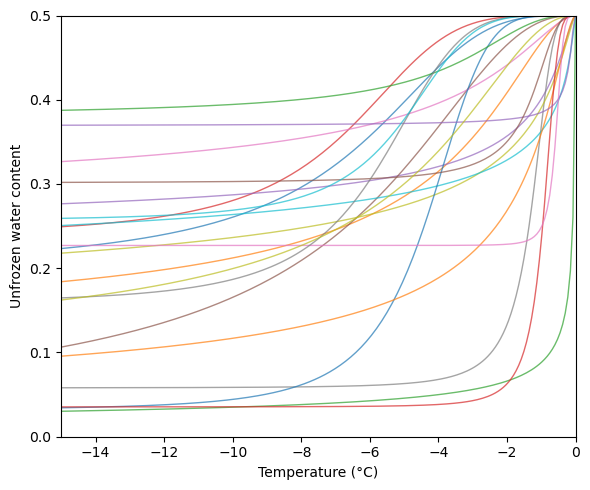

In [7]:
import matplotlib.pyplot as plt

rng = np.random.default_rng(2026)
show_ids = rng.choice(n_case, 20, replace=False)

plt.figure(figsize=(6, 5))

for i in show_ids:
    plt.plot(
        T_check,
        all_curves[i],
        linewidth=1.0,
        alpha=0.7
    )

plt.xlabel("Temperature (°C)")
plt.ylabel("Unfrozen water content")
plt.xlim(-15, 0)
plt.ylim(0, 0.5)
plt.tight_layout()
plt.show()

2. Generate temperature observations

In [8]:
import numpy as np
import pandas as pd


# =========================================================
# 1. Numerical configuration
# =========================================================
H = 0.6
dz = 0.0125

Nz = int(round(H / dz)) + 1

T_initial = -15.0

T_total_day = 5.0
Nt = 61
dt = T_total_day / (Nt - 1)

z = np.linspace(0.0, H, Nz)
t = np.linspace(0.0, T_total_day, Nt)


def T_top(time_day):
    """
    Prescribed upper boundary temperature.
    This is identical to the original training-data simulation.
    """
    if time_day <= 0.5:
        return -5.0
    else:
        return 0.0


print("Nz:", Nz)
print("Nt:", Nt)
print("dt:", dt)
print("z shape:", z.shape)
print("t shape:", t.shape)


# =========================================================
# 2. VG-type SFCC
# =========================================================
theta_sat = 0.5


def theta_vg(
    T,
    theta_res,
    alpha,
    n,
    theta_sat=0.5
):
    """
    VG-type SFCC:

    theta(T) = theta_res
             + (theta_sat - theta_res)
             * [1 + (alpha * |T|)^n]^(-m)

    m = 1 - 1/n
    """
    T = np.asarray(T, dtype=float)

    x = np.maximum(-T, 1e-6)
    m = 1.0 - 1.0 / n

    theta = (
        theta_res
        + (theta_sat - theta_res)
        * (1.0 + (alpha * x)**n)**(-m)
    )

    # T >= 0: saturated water content
    theta = np.where(
        T >= 0.0,
        theta_sat,
        theta
    )

    return np.clip(
        theta,
        0.0,
        theta_sat
    )


def theta_w(
    T,
    param_row,
    theta_sat=0.5
):
    """
    Unified SFCC interface for this VG OOD dataset.
    """

    form_id = int(param_row["form_id"])

    if form_id != 3:
        raise ValueError(
            f"This dataset expects form_id=3, "
            f"but received form_id={form_id}."
        )

    return theta_vg(
        T=T,
        theta_res=float(param_row["theta_res"]),
        alpha=float(param_row["alpha"]),
        n=float(param_row["n"]),
        theta_sat=theta_sat
    )


# =========================================================
# 3. Analytical temperature derivative of the VG SFCC
# =========================================================
def dtheta_dT_analytic(
    T,
    param_row,
    theta_sat=0.5
):
    """
    Analytical dtheta/dT for the VG-type SFCC.
    """

    T = np.asarray(T, dtype=float)

    theta_res = float(
        param_row["theta_res"]
    )

    alpha = float(
        param_row["alpha"]
    )

    n = float(
        param_row["n"]
    )

    m = 1.0 - 1.0 / n
    A = theta_sat - theta_res

    dtheta = np.zeros_like(
        T,
        dtype=float
    )

    # Only calculate the derivative below 0 °C
    mask = T < 0.0

    x = np.maximum(
        -T[mask],
        1e-12
    )

    y = (alpha * x)**n
    base = 1.0 + y

    dtheta[mask] = (
        A
        * m
        * n
        * alpha**n
        * x**(n - 1.0)
        * base**(-(m + 1.0))
    )

    # Same numerical bound as the original solver
    dtheta = np.clip(
        dtheta,
        0.0,
        5.0
    )

    return dtheta


# =========================================================
# 4. Thermal properties
# =========================================================

# Converted to the day-based time unit used by the solver
K_s = 8.80 * 86400.0
K_w = 0.56 * 86400.0
K_i = 2.26 * 86400.0

C_s = 2.13e6
C_w = 4.19e6
C_i = 2.13e6

rho_w = 1000.0
L = 3.34e5

n_porosity = theta_sat
theta_s_fixed = 1.0 - n_porosity


def compute_K(
    T,
    theta_u,
    param_row
):
    """
    Effective thermal conductivity.
    """

    theta_w_value = np.asarray(
        theta_u,
        dtype=float
    )

    theta_i = np.clip(
        n_porosity - theta_w_value,
        0.0,
        n_porosity
    )

    theta_s = theta_s_fixed

    K_value = (
        K_s**theta_s
        * K_w**theta_w_value
        * K_i**theta_i
    )

    return K_value


def compute_Ceff(
    T,
    theta_u,
    param_row,
    theta_sat=0.5
):
    """
    Apparent volumetric heat capacity.
    """

    T = np.asarray(
        T,
        dtype=float
    )

    theta_w_value = np.asarray(
        theta_u,
        dtype=float
    )

    theta_i = np.clip(
        n_porosity - theta_w_value,
        0.0,
        n_porosity
    )

    theta_s = theta_s_fixed

    C_T = (
        theta_s * C_s
        + theta_w_value * C_w
        + theta_i * C_i
    )

    dtheta_dT = dtheta_dT_analytic(
        T,
        param_row,
        theta_sat=theta_sat
    )

    C_eff = (
        C_T
        + L * rho_w * dtheta_dT
    )

    # Numerical safety lower bound
    C_eff = np.maximum(
        C_eff,
        1.0e3
    )

    return C_eff


# =========================================================
# 5. Tridiagonal solver
# =========================================================
def solve_tridiagonal(
    a,
    b,
    c,
    d
):
    """
    Solve a tridiagonal linear system.

    a: lower diagonal
    b: main diagonal
    c: upper diagonal
    d: right-hand side
    """

    a = np.array(
        a,
        dtype=float,
        copy=True
    )

    b = np.array(
        b,
        dtype=float,
        copy=True
    )

    c = np.array(
        c,
        dtype=float,
        copy=True
    )

    d = np.array(
        d,
        dtype=float,
        copy=True
    )

    n_equation = len(b)

    # Forward elimination
    for i in range(1, n_equation):

        factor = (
            a[i - 1]
            / b[i - 1]
        )

        b[i] = (
            b[i]
            - factor * c[i - 1]
        )

        d[i] = (
            d[i]
            - factor * d[i - 1]
        )

    # Back substitution
    solution = np.empty(
        n_equation,
        dtype=float
    )

    solution[-1] = (
        d[-1]
        / b[-1]
    )

    for i in range(
        n_equation - 2,
        -1,
        -1
    ):
        solution[i] = (
            d[i]
            - c[i] * solution[i + 1]
        ) / b[i]

    return solution


# =========================================================
# 6. Forward simulation for one SFCC
# =========================================================
def simulate_one_curve(
    param_row
):
    """
    Simulate the temperature field generated by one VG SFCC.

    Returns:
        T_field: shape (Nt, Nz)
    """

    T_field = np.full(
        (Nt, Nz),
        T_initial,
        dtype=float
    )

    dz_squared = dz**2

    for time_step in range(Nt - 1):

        time_next = t[time_step + 1]
        T_top_next = T_top(time_next)

        T_current = T_field[
            time_step
        ].copy()

        # SFCC
        theta_u = theta_w(
            T_current,
            param_row,
            theta_sat=theta_sat
        )

        # Thermal properties
        K = compute_K(
            T_current,
            theta_u,
            param_row
        )

        C_eff = compute_Ceff(
            T_current,
            theta_u,
            param_row,
            theta_sat=theta_sat
        )

        # Interface thermal conductivity
        K_half = 0.5 * (
            K[1:] + K[:-1]
        )

        # Internal nodes: 1 ... Nz-2
        n_internal = Nz - 2

        lower = np.zeros(
            n_internal - 1
        )

        main = np.zeros(
            n_internal
        )

        upper = np.zeros(
            n_internal - 1
        )

        rhs = np.zeros(
            n_internal
        )

        for j in range(1, Nz - 1):

            equation_id = j - 1

            K_left = K_half[j - 1]
            K_right = K_half[j]
            C_node = C_eff[j]

            lower_value = (
                -K_left / dz_squared
            )

            upper_value = (
                -K_right / dz_squared
            )

            main_value = (
                C_node / dt
                + (K_left + K_right)
                / dz_squared
            )

            rhs_value = (
                C_node / dt
                * T_current[j]
            )

            # Zero-flux lower boundary
            if j == 1:
                main_value += lower_value

            # Prescribed upper boundary
            if j == Nz - 2:
                rhs_value -= (
                    upper_value
                    * T_top_next
                )

            main[equation_id] = main_value
            rhs[equation_id] = rhs_value

            if equation_id > 0:
                lower[
                    equation_id - 1
                ] = lower_value

            if equation_id < n_internal - 1:
                upper[
                    equation_id
                ] = upper_value

        T_internal = solve_tridiagonal(
            lower,
            main,
            upper,
            rhs
        )

        # Save the next time step
        T_field[
            time_step + 1,
            1:-1
        ] = T_internal

        # Zero-flux lower boundary
        T_field[
            time_step + 1,
            0
        ] = T_field[
            time_step + 1,
            1
        ]

        # Prescribed upper boundary
        T_field[
            time_step + 1,
            -1
        ] = T_top_next

    return T_field


# =========================================================
# 7. Batch simulation
# =========================================================

N_OOD = 150

if len(form3_test) < N_OOD:
    raise ValueError(
        f"Only {len(form3_test)} VG curves are available, "
        f"but {N_OOD} are required."
    )

# If form3_test contains exactly 100 curves, all are used.
# If it still contains 220 curves, only the first 100 are used.
params_df = (
    form3_test
    .iloc[:N_OOD]
    .copy()
    .reset_index(drop=True)
)

print("Number of simulated VG curves:", len(params_df))

all_T = np.zeros(
    (N_OOD, Nt, Nz),
    dtype=np.float64
)

for i, row in params_df.iterrows():

    curve_id = int(
        row["curve_id"]
    )

    print(
        f"Simulating case "
        f"{i + 1}/{N_OOD}, "
        f"curve_id={curve_id}"
    )

    all_T[i] = simulate_one_curve(
        row
    )

    if not np.all(
        np.isfinite(all_T[i])
    ):
        raise FloatingPointError(
            f"Non-finite temperature detected "
            f"for case {i + 1}."
        )


# =========================================================
# 8. Prepare parameter array
# =========================================================
param_cols = [
    "form_id",
    "alpha",
    "beta",
    "theta_res",
    "gamma",
    "n"
]

params_arr = (
    params_df[param_cols]
    .fillna(0.0)
    .to_numpy(dtype=np.float32)
)

curve_ids = (
    params_df["curve_id"]
    .to_numpy(dtype=np.int64)
)

print("all_T shape:", all_T.shape)
print("params_arr shape:", params_arr.shape)
print("curve_ids shape:", curve_ids.shape)

print(
    "Temperature range:",
    all_T.min(),
    "to",
    all_T.max(),
    "°C"
)


# =========================================================
# 9. Extract the same 11 sensor observations
# =========================================================
sensor_offset = 0.05
sensor_spacing = 0.05
n_sensors = 11

sensor_z = (
    sensor_offset
    + sensor_spacing
    * np.arange(n_sensors)
)

sensor_idx = np.array(
    [
        np.argmin(
            np.abs(z - sensor_depth)
        )
        for sensor_depth in sensor_z
    ],
    dtype=int
)

all_T_sensor = all_T[
    :,
    :,
    sensor_idx
]

print("sensor_z:", sensor_z)
print("sensor_idx:", sensor_idx)
print(
    "all_T_sensor shape:",
    all_T_sensor.shape
)


# =========================================================
# 10. Final checks
# =========================================================
assert all_T.shape == (
    N_OOD,
    61,
    49
)

assert all_T_sensor.shape == (
    N_OOD,
    61,
    11
)

assert params_arr.shape == (
    N_OOD,
    6
)

assert np.all(
    np.isfinite(all_T)
)

assert np.all(
    np.isfinite(all_T_sensor)
)

assert np.all(
    params_arr[:, 0] == 3
)

print("All checks passed.")


# =========================================================
# 11. Save OOD dataset
# =========================================================
output_file = (
    "frozen_soil_sensor_dataset_test_VG_OOD_150.npz"
)

np.savez(
    output_file,
    all_T=all_T,
    all_T_sensor=all_T_sensor,
    params_arr=params_arr,
    curve_ids=curve_ids,
    t=t,
    z=z,
    sensor_z=sensor_z,
    sensor_idx=sensor_idx
)

print("Saved OOD dataset:", output_file)

Nz: 49
Nt: 61
dt: 0.08333333333333333
z shape: (49,)
t shape: (61,)
Number of simulated VG curves: 150
Simulating case 1/150, curve_id=1
Simulating case 2/150, curve_id=2
Simulating case 3/150, curve_id=3
Simulating case 4/150, curve_id=4
Simulating case 5/150, curve_id=5
Simulating case 6/150, curve_id=6
Simulating case 7/150, curve_id=7
Simulating case 8/150, curve_id=8
Simulating case 9/150, curve_id=9
Simulating case 10/150, curve_id=10
Simulating case 11/150, curve_id=11
Simulating case 12/150, curve_id=12
Simulating case 13/150, curve_id=13
Simulating case 14/150, curve_id=14
Simulating case 15/150, curve_id=15
Simulating case 16/150, curve_id=16
Simulating case 17/150, curve_id=17
Simulating case 18/150, curve_id=18
Simulating case 19/150, curve_id=19
Simulating case 20/150, curve_id=20
Simulating case 21/150, curve_id=21
Simulating case 22/150, curve_id=22
Simulating case 23/150, curve_id=23
Simulating case 24/150, curve_id=24
Simulating case 25/150, curve_id=25
Simulating case

3. OOD test preparation

In [9]:
import torch
import numpy as np

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

# 模型输入：(case, sensor, time)
X_ood = (
    torch.from_numpy(all_T_sensor)
    .permute(0, 2, 1)
    .float()
    .to(device)
)

T_eval_np = np.linspace(
    -15.0,
    0.0,
    50
).astype(np.float32)

T_eval = (
    torch.from_numpy(T_eval_np)
    .float()
    .to(device)
)

theta_true_ood = np.stack([
    theta_vg(
        T_eval_np,
        theta_res=row["theta_res"],
        alpha=row["alpha"],
        n=row["n"],
        theta_sat=0.5
    )
    for _, row in params_df.iterrows()
]).astype(np.float32)

print("X_ood shape:", X_ood.shape)
print(
    "theta_true_ood shape:",
    theta_true_ood.shape
)

X_ood shape: torch.Size([150, 11, 61])
theta_true_ood shape: (150, 50)


3. Zero-shot OOD comparison

In [10]:
import os
import time
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F


# =========================================================
# 1. Configuration
# =========================================================
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("Using device:", device)

ood_dataset_path = (
    r"D:\UW Madsion\Operator\SFC_inverse\Operator experiment"
    r"\SC_DION\Baseline_two parameter_Train_80\Results Plot"
    r"\frozen_soil_sensor_dataset_test_VG_OOD_150.npz"
)

supervised_weight_path = (
    r"D:\UW Madsion\Operator\SFC_inverse\Operator experiment"
    r"\SC_DION\Baseline_supervised_DION_Train_80"
    r"\supervised_dion_train_80.pt"
)

parametric_weight_path = (
    r"D:\UW Madsion\Operator\SFC_inverse\Operator experiment"
    r"\SC_DION\Baseline_two parameter_Train_80"
    r"\Train_process_two parameter_train80"
    r"\two_parameter_operator_train_80.pt"
)

sc_dion_weight_path = (
    r"D:\UW Madsion\Operator\SFC_inverse\Operator experiment"
    r"\SC_DION\Train_80\Train_process_train80"
    r"\deeponet_sfcc_operator_train_80.pt"
)

for file_path in [
    ood_dataset_path,
    supervised_weight_path,
    parametric_weight_path,
    sc_dion_weight_path
]:
    if not os.path.isfile(file_path):
        raise FileNotFoundError(file_path)


# =========================================================
# 2. Load VG OOD dataset
# =========================================================
ood_data = np.load(ood_dataset_path)

all_T_sensor_ood = ood_data["all_T_sensor"]
params_arr_ood = ood_data["params_arr"]
curve_ids_ood = ood_data["curve_ids"]

print(
    "all_T_sensor:",
    all_T_sensor_ood.shape
)

print(
    "params_arr:",
    params_arr_ood.shape
)

print(
    "curve_ids:",
    curve_ids_ood.shape
)

# Expected input: (case, sensor, time)
X_ood = (
    torch.from_numpy(all_T_sensor_ood)
    .permute(0, 2, 1)
    .float()
    .to(device)
)

n_case, n_sensors, Nt = X_ood.shape

assert n_case == 150
assert n_sensors == 11
assert Nt == 61
assert np.all(params_arr_ood[:, 0] == 3)

T_eval_np = np.linspace(
    -15.0,
    0.0,
    50,
    dtype=np.float32
)

T_eval = (
    torch.from_numpy(T_eval_np)
    .float()
    .to(device)
)

print("X_ood:", X_ood.shape)
print("T_eval:", T_eval.shape)


# =========================================================
# 3. Construct reference VG SFCCs
# =========================================================
# params_arr column order:
# [form_id, alpha, beta, theta_res, gamma, n]

alpha_true = params_arr_ood[:, 1:2]
theta_res_true = params_arr_ood[:, 3:4]
n_true = params_arr_ood[:, 5:6]

m_true = 1.0 - 1.0 / n_true

T_reference = T_eval_np.reshape(1, -1)
x_reference = np.maximum(
    -T_reference,
    1e-6
)

theta_true_ood = (
    theta_res_true
    + (0.5 - theta_res_true)
    * (
        1.0
        + (alpha_true * x_reference)**n_true
    )**(-m_true)
)

# At 0 °C, set theta to saturation
theta_true_ood[:, T_eval_np >= 0.0] = 0.5

theta_true_ood = np.clip(
    theta_true_ood,
    0.0,
    0.5
).astype(np.float32)

print(
    "Reference VG SFCC:",
    theta_true_ood.shape
)


# =========================================================
# 4. Common branch network
# =========================================================
class BranchCNN(nn.Module):

    def __init__(
        self,
        n_sensors,
        latent_dim=8
    ):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv1d(
                n_sensors,
                16,
                kernel_size=5,
                padding=2
            ),
            nn.ReLU(),
            nn.Conv1d(
                16,
                32,
                kernel_size=5,
                padding=2
            ),
            nn.ReLU()
        )

        self.pool = nn.AdaptiveAvgPool1d(1)
        self.ln = nn.LayerNorm(32)
        self.fc = nn.Linear(
            32,
            latent_dim
        )

    def forward(self, x):

        h = self.conv(x)
        h = self.pool(h).squeeze(-1)
        h = self.ln(h)

        return self.fc(h)


# =========================================================
# 5. Functional DION architecture
# Used by both Supervised DION and SC-DION
# =========================================================
class TrunkNet(nn.Module):

    def __init__(
        self,
        latent_dim=8,
        hidden=64
    ):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(1, hidden),
            nn.Tanh(),
            nn.Linear(hidden, hidden),
            nn.Tanh(),
            nn.Linear(hidden, latent_dim)
        )

    def forward(self, T_query):

        x = T_query.unsqueeze(-1)

        return self.net(x)


class InverseDeepONetMonotone(nn.Module):

    def __init__(
        self,
        n_sensors,
        latent_dim=8,
        theta_sat=0.5
    ):
        super().__init__()

        self.branch = BranchCNN(
            n_sensors,
            latent_dim
        )

        self.trunk = TrunkNet(
            latent_dim=latent_dim,
            hidden=64
        )

        self.theta_sat = theta_sat
        self.latent_dim = latent_dim

        self.fc_res = nn.Linear(
            latent_dim,
            1
        )

        self.fc_scale = nn.Linear(
            latent_dim,
            1
        )

    def forward(
        self,
        X_sensor,
        T_query
    ):
        T_query = T_query.to(
            X_sensor.device
        )

        batch_size = X_sensor.shape[0]
        n_temperature = T_query.numel()

        mask_negative = T_query < 0.0
        mask_nonnegative = ~mask_negative

        negative_ids = torch.nonzero(
            mask_negative,
            as_tuple=False
        ).squeeze(-1)

        nonnegative_ids = torch.nonzero(
            mask_nonnegative,
            as_tuple=False
        ).squeeze(-1)

        T_negative = T_query[
            negative_ids
        ]

        branch_feature = self.branch(
            X_sensor
        )

        theta_res_fraction = torch.sigmoid(
            self.fc_res(branch_feature)
        )

        theta_res = (
            theta_res_fraction
            * self.theta_sat
        )

        trunk_feature = self.trunk(
            T_negative
        )

        raw_increment = torch.matmul(
            branch_feature,
            trunk_feature.T
        )

        scale = (
            0.2
            + 5.0
            * torch.sigmoid(
                self.fc_scale(
                    branch_feature
                )
            )
        )

        positive_increment = (
            F.softplus(raw_increment)
            * scale
        )

        cumulative_increment = torch.cumsum(
            positive_increment,
            dim=1
        )

        normalized_shape = (
            cumulative_increment
            / (
                cumulative_increment[:, -1:]
                + 1e-6
            )
        )

        theta_negative = (
            theta_res
            + (
                self.theta_sat
                - theta_res
            )
            * normalized_shape
        )

        theta = torch.zeros(
            batch_size,
            n_temperature,
            device=X_sensor.device
        )

        if negative_ids.numel() > 0:
            theta[:, negative_ids] = (
                theta_negative
            )

        if nonnegative_ids.numel() > 0:
            theta[:, nonnegative_ids] = (
                self.theta_sat
            )

        return theta


# =========================================================
# 6. Parametric baseline architecture
# =========================================================
class InverseTwoParameter(nn.Module):

    def __init__(
        self,
        n_sensors,
        latent_dim=8,
        theta_sat=0.5,
        theta_res_max=0.4,
        gamma_min=0.0,
        gamma_max=10.0
    ):
        super().__init__()

        self.branch = BranchCNN(
            n_sensors,
            latent_dim
        )

        self.fc_theta_res = nn.Linear(
            latent_dim,
            1
        )

        self.fc_gamma = nn.Linear(
            latent_dim,
            1
        )

        self.theta_sat = theta_sat
        self.theta_res_max = theta_res_max
        self.gamma_min = gamma_min
        self.gamma_max = gamma_max

    def predict_parameters(
        self,
        X_sensor
    ):
        branch_feature = self.branch(
            X_sensor
        )

        theta_res = (
            self.theta_res_max
            * torch.sigmoid(
                self.fc_theta_res(
                    branch_feature
                )
            )
        )

        gamma = (
            self.gamma_min
            + (
                self.gamma_max
                - self.gamma_min
            )
            * torch.sigmoid(
                self.fc_gamma(
                    branch_feature
                )
            )
        )

        return theta_res, gamma

    def forward(
        self,
        X_sensor,
        T_query
    ):
        T_query = T_query.to(
            X_sensor.device
        )

        theta_res, gamma = (
            self.predict_parameters(
                X_sensor
            )
        )

        x = torch.clamp(
            -T_query,
            min=0.0
        ).reshape(1, -1)

        theta = (
            theta_res
            + (
                self.theta_sat
                - theta_res
            )
            * torch.exp(
                -((x / gamma)**2)
            )
        )

        return theta


# =========================================================
# 7. Instantiate and load the three trained models
# =========================================================
supervised_model = (
    InverseDeepONetMonotone(
        n_sensors=n_sensors,
        latent_dim=8,
        theta_sat=0.5
    )
    .to(device)
)

parametric_model = (
    InverseTwoParameter(
        n_sensors=n_sensors,
        latent_dim=8,
        theta_sat=0.5,
        theta_res_max=0.4,
        gamma_min=0.0,
        gamma_max=10.0
    )
    .to(device)
)

sc_dion_model = (
    InverseDeepONetMonotone(
        n_sensors=n_sensors,
        latent_dim=8,
        theta_sat=0.5
    )
    .to(device)
)

supervised_state = torch.load(
    supervised_weight_path,
    map_location=device
)

parametric_state = torch.load(
    parametric_weight_path,
    map_location=device
)

sc_dion_state = torch.load(
    sc_dion_weight_path,
    map_location=device
)

supervised_model.load_state_dict(
    supervised_state
)

parametric_model.load_state_dict(
    parametric_state
)

sc_dion_model.load_state_dict(
    sc_dion_state
)

supervised_model.eval()
parametric_model.eval()
sc_dion_model.eval()

print("All three model weights loaded.")


# =========================================================
# 8. Inference helper
# =========================================================
def run_inference(
    model,
    X_input,
    T_query
):
    model.eval()

    # GPU warm-up
    with torch.no_grad():
        _ = model(
            X_input,
            T_query
        )

    if device.type == "cuda":
        torch.cuda.synchronize()

    start_time = time.perf_counter()

    with torch.no_grad():
        prediction = model(
            X_input,
            T_query
        )

    if device.type == "cuda":
        torch.cuda.synchronize()

    inference_time = (
        time.perf_counter()
        - start_time
    )

    return (
        prediction.cpu().numpy(),
        inference_time
    )


# =========================================================
# 9. Run zero-shot OOD inference
# =========================================================
theta_pred_supervised, time_supervised = (
    run_inference(
        supervised_model,
        X_ood,
        T_eval
    )
)

theta_pred_parametric, time_parametric = (
    run_inference(
        parametric_model,
        X_ood,
        T_eval
    )
)

theta_pred_sc_dion, time_sc_dion = (
    run_inference(
        sc_dion_model,
        X_ood,
        T_eval
    )
)

print(
    "Supervised prediction:",
    theta_pred_supervised.shape
)

print(
    "Parametric prediction:",
    theta_pred_parametric.shape
)

print(
    "SC-DION prediction:",
    theta_pred_sc_dion.shape
)


# =========================================================
# 10. Accuracy metrics
# =========================================================
def calculate_metrics(
    theta_true,
    theta_pred
):
    error = (
        theta_pred
        - theta_true
    )

    global_rmse = np.sqrt(
        np.mean(error**2)
    )

    ss_res_global = np.sum(
        error**2
    )

    ss_tot_global = np.sum(
        (
            theta_true
            - np.mean(theta_true)
        )**2
    )

    global_r2 = (
        1.0
        - ss_res_global
        / ss_tot_global
    )

    case_rmse = np.sqrt(
        np.mean(
            error**2,
            axis=1
        )
    )

    case_true_mean = np.mean(
        theta_true,
        axis=1,
        keepdims=True
    )

    case_ss_res = np.sum(
        error**2,
        axis=1
    )

    case_ss_tot = np.sum(
        (
            theta_true
            - case_true_mean
        )**2,
        axis=1
    )

    case_r2 = (
        1.0
        - case_ss_res
        / case_ss_tot
    )

    return {
        "global_rmse": global_rmse,
        "global_r2": global_r2,
        "case_rmse": case_rmse,
        "case_r2": case_r2
    }


metrics_supervised = calculate_metrics(
    theta_true_ood,
    theta_pred_supervised
)

metrics_parametric = calculate_metrics(
    theta_true_ood,
    theta_pred_parametric
)

metrics_sc_dion = calculate_metrics(
    theta_true_ood,
    theta_pred_sc_dion
)


# =========================================================
# 11. Summary table
# =========================================================
summary_table = pd.DataFrame({
    "Method": [
        "Supervised DION",
        "Solver-consistent parametric baseline",
        "SC-DION"
    ],
    "Global OOD RMSE": [
        metrics_supervised["global_rmse"],
        metrics_parametric["global_rmse"],
        metrics_sc_dion["global_rmse"]
    ],
    "Global OOD R2": [
        metrics_supervised["global_r2"],
        metrics_parametric["global_r2"],
        metrics_sc_dion["global_r2"]
    ],
    "Median case-wise RMSE": [
        np.median(
            metrics_supervised["case_rmse"]
        ),
        np.median(
            metrics_parametric["case_rmse"]
        ),
        np.median(
            metrics_sc_dion["case_rmse"]
        )
    ],
    "Median case-wise R2": [
        np.median(
            metrics_supervised["case_r2"]
        ),
        np.median(
            metrics_parametric["case_r2"]
        ),
        np.median(
            metrics_sc_dion["case_r2"]
        )
    ],
    "Inference time for 150 cases (ms)": [
        time_supervised * 1000.0,
        time_parametric * 1000.0,
        time_sc_dion * 1000.0
    ]
})

display(
    summary_table.round(6)
)


# =========================================================
# 12. Relative RMSE increase from the ID Test220
# =========================================================
id_rmse = {
    "Supervised DION": 0.027230,
    "Solver-consistent parametric baseline": 0.01697286,
    "SC-DION": 0.03201957
}

summary_table[
    "Relative RMSE increase (%)"
] = [
    (
        metrics_supervised["global_rmse"]
        / id_rmse["Supervised DION"]
        - 1.0
    ) * 100.0,

    (
        metrics_parametric["global_rmse"]
        / id_rmse[
            "Solver-consistent parametric baseline"
        ]
        - 1.0
    ) * 100.0,

    (
        metrics_sc_dion["global_rmse"]
        / id_rmse["SC-DION"]
        - 1.0
    ) * 100.0
]

display(
    summary_table.round(6)
)


# =========================================================
# 13. Save all OOD results
# =========================================================
np.savez(
    "VG_OOD_comparison_three_models_150.npz",

    T_eval=T_eval_np,
    theta_true=theta_true_ood,

    theta_pred_supervised=(
        theta_pred_supervised
    ),

    theta_pred_parametric=(
        theta_pred_parametric
    ),

    theta_pred_sc_dion=(
        theta_pred_sc_dion
    ),

    supervised_case_rmse=(
        metrics_supervised["case_rmse"]
    ),

    parametric_case_rmse=(
        metrics_parametric["case_rmse"]
    ),

    sc_dion_case_rmse=(
        metrics_sc_dion["case_rmse"]
    ),

    supervised_case_r2=(
        metrics_supervised["case_r2"]
    ),

    parametric_case_r2=(
        metrics_parametric["case_r2"]
    ),

    sc_dion_case_r2=(
        metrics_sc_dion["case_r2"]
    )
)

summary_table.to_csv(
    "VG_OOD_comparison_three_models_150.csv",
    index=False
)

print(
    "Saved:"
    "\n  VG_OOD_comparison_three_models_150.npz"
    "\n  VG_OOD_comparison_three_models_150.csv"
)

Using device: cuda
all_T_sensor: (150, 61, 11)
params_arr: (150, 6)
curve_ids: (150,)
X_ood: torch.Size([150, 11, 61])
T_eval: torch.Size([50])
Reference VG SFCC: (150, 50)
All three model weights loaded.
Supervised prediction: (150, 50)
Parametric prediction: (150, 50)
SC-DION prediction: (150, 50)


,Method,Global OOD RMSE,Global OOD R2,Median case-wise RMSE,Median case-wise R2,Inference time for 150 cases (ms)
0,Supervised DION,0.061710,0.790554,0.031824,0.778437,2.1739
1,Solver-consistent parametric baseline,0.065336,0.765217,0.031965,0.832752,1.2390
2,SC-DION,0.063999,0.774731,0.033113,0.833748,1.8242


,Method,Global OOD RMSE,Global OOD R2,Median case-wise RMSE,Median case-wise R2,Inference time for 150 cases (ms),Relative RMSE increase (%)
0,Supervised DION,0.061710,0.790554,0.031824,0.778437,2.1739,126.626770
1,Solver-consistent parametric baseline,0.065336,0.765217,0.031965,0.832752,1.2390,284.946840
2,SC-DION,0.063999,0.774731,0.033113,0.833748,1.8242,99.874793


Saved:
  VG_OOD_comparison_three_models_150.npz
  VG_OOD_comparison_three_models_150.csv


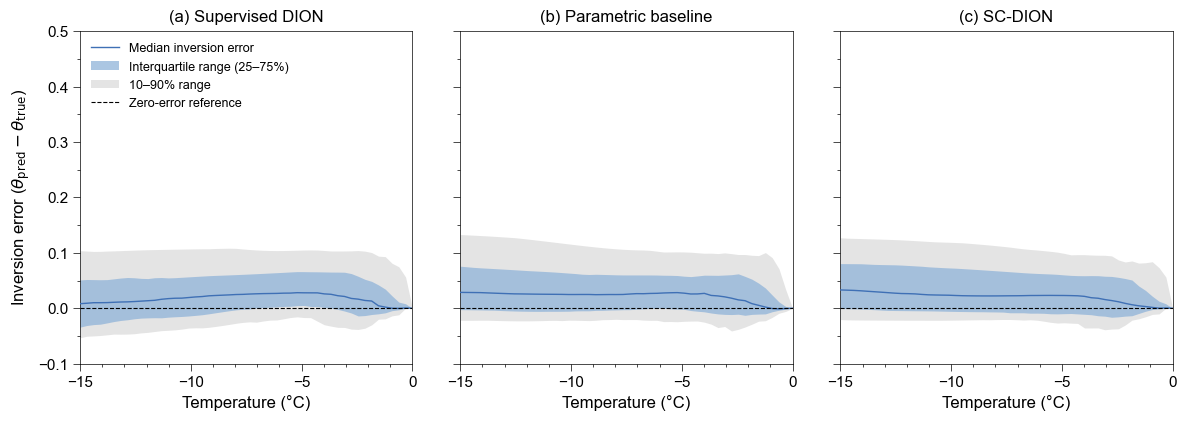

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from matplotlib.patches import Patch
from matplotlib.lines import Line2D


# =========================================================
# 1. Adjustable plotting parameters
# =========================================================
FIG_SIZE = (12.0, 4.0)

FONT_SIZE = 11
LABEL_SIZE = 12
TITLE_SIZE = 12
LEGEND_SIZE = 9

LINE_WIDTH = 1.0
FRAME_WIDTH = 0.5

MEDIAN_COLOR = "#3F70B5"
IQR_COLOR = "#8FB3D9"
RANGE_COLOR = "#D9D9D9"

IQR_ALPHA = 0.75
RANGE_ALPHA = 0.70

X_MIN = -15.0
X_MAX = 0.0

# 三个面板必须使用相同纵坐标范围
Y_MIN = -0.10
Y_MAX = 0.50

X_MAJOR_INTERVAL = 5.0
X_MINOR_INTERVAL = 1.0

Y_MAJOR_INTERVAL = 0.10
Y_MINOR_INTERVAL = 0.05


# =========================================================
# 2. Model predictions
# =========================================================
model_results = [
    (
        "(a) Supervised DION",
        theta_pred_supervised
    ),
    (
        "(b) Parametric baseline",
        theta_pred_parametric
    ),
    (
        "(c) SC-DION",
        theta_pred_sc_dion
    )
]


# =========================================================
# 3. Global figure style
# =========================================================
plt.rcParams.update({
    "font.family": "Arial",
    "font.size": FONT_SIZE,
    "axes.linewidth": FRAME_WIDTH,
    "xtick.direction": "out",
    "ytick.direction": "out",
})


# =========================================================
# 4. Plot
# =========================================================
fig, axes = plt.subplots(
    1,
    3,
    figsize=FIG_SIZE,
    sharex=True,
    sharey=True
)

for ax, (title, theta_prediction) in zip(
    axes,
    model_results
):

    # Signed inversion error
    error = (
        theta_prediction
        - theta_true_ood
    )

    median_error = np.median(
        error,
        axis=0
    )

    q10 = np.quantile(
        error,
        0.10,
        axis=0
    )

    q25 = np.quantile(
        error,
        0.25,
        axis=0
    )

    q75 = np.quantile(
        error,
        0.75,
        axis=0
    )

    q90 = np.quantile(
        error,
        0.90,
        axis=0
    )

    # Outer 10–90% range
    ax.fill_between(
        T_eval_np,
        q10,
        q90,
        color=RANGE_COLOR,
        alpha=RANGE_ALPHA,
        linewidth=0.0,
        zorder=1
    )

    # Interquartile range
    ax.fill_between(
        T_eval_np,
        q25,
        q75,
        color=IQR_COLOR,
        alpha=IQR_ALPHA,
        linewidth=0.0,
        zorder=2
    )

    # Median signed error
    ax.plot(
        T_eval_np,
        median_error,
        color=MEDIAN_COLOR,
        linewidth=LINE_WIDTH,
        zorder=3
    )

    # Zero-error reference
    ax.axhline(
        0.0,
        color="black",
        linestyle="--",
        linewidth=0.8,
        zorder=4
    )

    ax.set_title(
        title,
        fontsize=TITLE_SIZE,
        pad=7
    )

    ax.set_xlim(
        X_MIN,
        X_MAX
    )

    ax.set_ylim(
        Y_MIN,
        Y_MAX
    )

    ax.set_xlabel(
        "Temperature (°C)",
        fontsize=LABEL_SIZE
    )

    # 每个子图保持正方形
    ax.set_box_aspect(1)

    # Major and minor ticks
    ax.xaxis.set_major_locator(
        MultipleLocator(
            X_MAJOR_INTERVAL
        )
    )

    ax.xaxis.set_minor_locator(
        MultipleLocator(
            X_MINOR_INTERVAL
        )
    )

    ax.yaxis.set_major_locator(
        MultipleLocator(
            Y_MAJOR_INTERVAL
        )
    )

    ax.yaxis.set_minor_locator(
        MultipleLocator(
            Y_MINOR_INTERVAL
        )
    )

    ax.tick_params(
        axis="both",
        which="major",
        direction="out",
        length=5,
        width=FRAME_WIDTH,
        labelsize=FONT_SIZE,
        top=False,
        right=False
    )

    ax.tick_params(
        axis="both",
        which="minor",
        direction="out",
        length=2.5,
        width=FRAME_WIDTH,
        top=False,
        right=False
    )

    for spine in ax.spines.values():
        spine.set_linewidth(
            FRAME_WIDTH
        )


# Shared y-axis label
axes[0].set_ylabel(
    r"Inversion error ($\theta_{\mathrm{pred}}-\theta_{\mathrm{true}}$)",
    fontsize=LABEL_SIZE
)


# =========================================================
# 5. Legend
# =========================================================
legend_handles = [
    Line2D(
        [0],
        [0],
        color=MEDIAN_COLOR,
        linewidth=LINE_WIDTH,
        label="Median inversion error"
    ),
    Patch(
        facecolor=IQR_COLOR,
        alpha=IQR_ALPHA,
        edgecolor="none",
        label="Interquartile range (25–75%)"
    ),
    Patch(
        facecolor=RANGE_COLOR,
        alpha=RANGE_ALPHA,
        edgecolor="none",
        label="10–90% range"
    ),
    Line2D(
        [0],
        [0],
        color="black",
        linestyle="--",
        linewidth=0.8,
        label="Zero-error reference"
    )
]

axes[0].legend(
    handles=legend_handles,
    loc="upper left",
    frameon=False,
    fontsize=LEGEND_SIZE,
    handlelength=2.2
)


# =========================================================
# 6. Save
# =========================================================
fig.tight_layout(
    w_pad=2.0
)

plt.savefig(
    "temperature_resolved_VG_OOD_errors_three_models_150.png",
    dpi=600,
    bbox_inches="tight"
)

plt.savefig(
    "temperature_resolved_VG_OOD_errors_three_models_150.pdf",
    bbox_inches="tight"
)

plt.show()